# Single Asset Backtest with ml4t-backtest

**Docker image**: `ml4t`

This notebook introduces the **ml4t-backtest** event-driven backtesting engine.
We implement the RSI mean-reversion rule from notebook 03 (VectorBT) as a
sequence of decisions, pending orders, fills, and portfolio-state updates.

## When to Use ml4t-backtest vs VectorBT

| Question | ml4t-backtest | VectorBT |
|----------|---------------|----------|
| **Natural representation** | Sequential decisions and state transitions | Timestamped arrays and portfolio signals |
| **State exposure** | Orders, fills, cash, and positions are explicit | State is expressed through vectorized portfolio rules |
| **Research strength** | Path-dependent strategy logic | Fast parameter and signal analysis |
| **Credibility condition** | Engine settings match the trading protocol | Array semantics match the trading protocol |

Neither representation is realistic by default. Credibility comes from explicit,
tested assumptions about information timing, fills, sizing, costs, and accounting.

**Learning Objectives:**
1. Implement a production-style `Strategy` class with `on_data` callbacks.
2. Run an event-driven backtest with next-open execution and explicit costs.
3. Reconcile fills, closed-trade P&L, and a protocol-matched benchmark.

**Book Reference:** Chapter 16, Sections 16.3-16.5 (simulation workflow and reporting).

**Prerequisites:** Complete [`03_single_asset_vectorbt`](03_single_asset_vectorbt.ipynb) first.

## Key Concepts Introduced

1. **Strategy class**: Encapsulates trading logic in `on_data()` method
2. **DataFeed**: Combines OHLCV prices with context data (indicators)
3. **Engine**: Orchestrates backtest execution with commission/slippage
4. **Broker**: Manages orders, positions, and portfolio state
5. **ExecutionMode**: Controls order fill timing (same-bar vs next-bar)

## Strategy: RSI Mean Reversion on BTC

- **Long Entry**: RSI < 30 (oversold)
- **Exit**: RSI > 70 (overbought)
- **Position Size**: 95% of capital per trade
- **Transaction Costs**: 10 bps commission + 5 bps slippage

## Setup

In [1]:
"""Single-asset event-driven backtest with explicit timing, sizing, and cost accounting."""

from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.analytics import MAEMFEAnalyzer, TradeAnalyzer
from ml4t.backtest.config import ShareType
from ml4t.backtest.sessions import SessionConfig, compute_session_pnl
from plotly.subplots import make_subplots

from data import load_crypto_perps
from utils.paths import get_output_dir
from utils.style import COLORS

In [2]:
# Production defaults - Papermill injects overrides for CI
START_DATE = "2020-01-01"
END_DATE = "2024-01-01"
INITIAL_CASH = 100_000
FEES = 0.001  # 10 bps per trade
SLIPPAGE = 0.0005  # 5 bps slippage
RSI_PERIOD = 14
RSI_LOWER = 30  # Oversold threshold
RSI_UPPER = 70  # Overbought threshold
POSITION_SIZE = 0.95  # 95% of capital per trade

In [3]:
display(
    Markdown(
        f"The rule uses a **{RSI_PERIOD}-day RSI**, enters below **{RSI_LOWER}**, "
        f"exits above **{RSI_UPPER}**, and targets **{POSITION_SIZE:.0%}** exposure. "
        f"Each fill pays a **{FEES:.2%} fee** plus **{SLIPPAGE:.2%} slippage**."
    )
)

The rule uses a **14-day RSI**, enters below **30**, exits above **70**, and targets **95%** exposure. Each fill pays a **0.10% fee** plus **0.05% slippage**.

## 1. Data Acquisition

Load BTC/USDT perpetual bars, aggregate the three 8-hour observations in each UTC day, and
retain the canonical `symbol` and `timestamp` keys. UTC-day aggregation is a calendar convention
for a continuously traded market, not an exchange session close.

In [4]:
_crypto = load_crypto_perps(
    symbols=["BTCUSDT"],
    start_date=START_DATE,
    end_date=END_DATE,
)
btc_df = (
    _crypto.filter(
        (pl.col("symbol") == "BTCUSDT")
        & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
        & (pl.col("timestamp") < pl.lit(END_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
    )
    .sort("timestamp")
    .with_columns(pl.col("timestamp").dt.replace_time_zone(None))
    .group_by_dynamic("timestamp", every="1d", group_by="symbol")
    .agg(
        pl.col("open").first(),
        pl.col("high").max(),
        pl.col("low").min(),
        pl.col("close").last(),
        pl.col("volume").sum(),
    )
    .sort(["symbol", "timestamp"])
)

prices_df = btc_df

Canonical keys must remain unique after aggregation. Positive, internally consistent OHLC bars
protect both the indicator and the broker from malformed inputs.

In [5]:
assert prices_df.n_unique(["symbol", "timestamp"]) == len(prices_df)
assert prices_df["symbol"].unique().to_list() == ["BTCUSDT"]
price_columns = ["open", "high", "low", "close"]
assert prices_df.select(pl.col(price_columns).is_not_null().all()).row(0) == (True,) * 4
assert prices_df.select((pl.col(price_columns) > 0).all()).row(0) == (True,) * 4
assert prices_df.select((pl.col("high") >= pl.max_horizontal("open", "close", "low")).all()).item()
assert prices_df.select((pl.col("low") <= pl.min_horizontal("open", "close", "high")).all()).item()
assert len(prices_df) > RSI_PERIOD

print(f"Loaded {len(prices_df):,} daily bars from local crypto dataset")
print(f"Date range: {prices_df['timestamp'].min()} to {prices_df['timestamp'].max()}")

Loaded 1,461 daily bars from local crypto dataset
Date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00


## 2. RSI Indicator Calculation

Compute the same simple rolling gain/loss RSI used by VectorBT's default indicator.

In [6]:
def compute_rsi(close: pl.Series, period: int = 14) -> pl.Series:
    """Compute RSI from simple rolling mean gains and losses."""
    delta = close.diff()
    gain = delta.clip(lower_bound=0.0)
    loss = (-delta).clip(lower_bound=0.0)
    avg_gain = gain.rolling_mean(window_size=period, min_samples=period)
    avg_loss = loss.rolling_mean(window_size=period, min_samples=period)

    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


# Compute RSI and add to context
rsi_values = compute_rsi(prices_df["close"], RSI_PERIOD)

# Create context DataFrame with RSI
context_df = prices_df.select(["timestamp"]).with_columns(rsi_values.alias("rsi"))

rsi_valid = context_df["rsi"].drop_nulls().drop_nans()
assert len(rsi_valid) <= len(context_df) - RSI_PERIOD
assert rsi_valid.is_between(0, 100, closed="both").all()
print(f"RSI Statistics ({len(rsi_valid)}/{len(context_df)} valid):")
print(f"  Mean: {rsi_valid.mean():.1f}")
print(f"  Std:  {rsi_valid.std():.1f}")
print(f"  Min:  {rsi_valid.min():.1f}")
print(f"  Max:  {rsi_valid.max():.1f}")

RSI Statistics (1447/1461 valid):
  Mean: 53.3
  Std:  17.8
  Min:  6.2
  Max:  99.4


In [7]:
# Visualize price and RSI
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.7, 0.3],
    subplot_titles=["BTC/USDT Price", "RSI (14)"],
)

fig.add_trace(
    go.Scatter(
        x=prices_df["timestamp"].to_list(),
        y=prices_df["close"].to_list(),
        name="BTC",
        line=dict(color=COLORS["blue"]),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=context_df["timestamp"].to_list(),
        y=context_df["rsi"].to_list(),
        name="RSI",
        line=dict(color=COLORS["amber"]),
    ),
    row=2,
    col=1,
)

# Add RSI threshold lines
fig.add_hline(y=RSI_LOWER, line_dash="dash", line_color=COLORS["positive"], row=2, col=1)
_ = fig.add_hline(y=RSI_UPPER, line_dash="dash", line_color=COLORS["negative"], row=2, col=1)

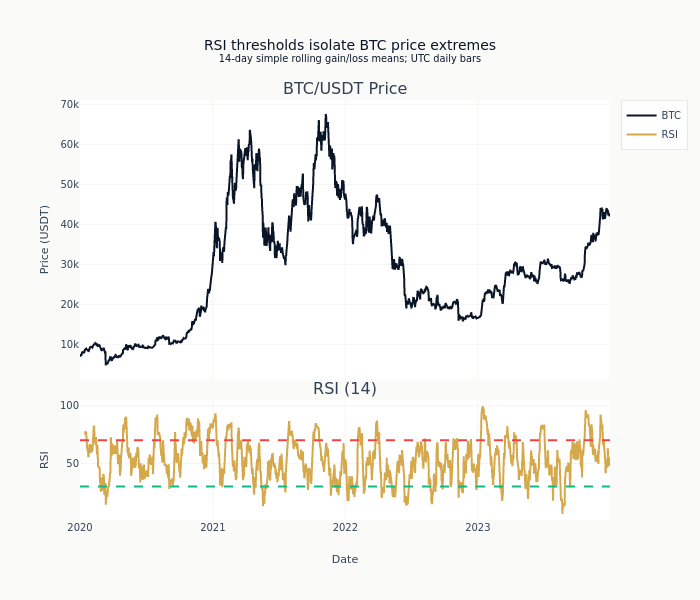

In [8]:
# Layout and display
fig.update_layout(
    height=600,
    title=(
        "RSI thresholds isolate BTC price extremes"
        "<br><sup>14-day simple rolling gain/loss means; UTC daily bars</sup>"
    ),
    showlegend=True,
    xaxis2_title="Date",
    yaxis_title="Price (USDT)",
    yaxis2_title="RSI",
)
fig.show()

## 3. Define Strategy Class

The `Strategy` class is the heart of ml4t-backtest. You subclass it and implement
the `on_data()` method, which is called for each bar during the backtest.

### Strategy Best Practices

1. **Initialize parameters in `__init__`**: Pass strategy parameters (thresholds,
   lookbacks) to `__init__`, not hard-coded in `on_data()`.

2. **Use `broker.get_position()` for position checks**: Returns `None` if no position,
   or a `Position` object with `quantity`, `entry_price`, `unrealized_pnl`.

3. **Access context data via `context.get()`**: Indicators precomputed and passed
   via `context_df` are available here. Always check for `None`/`NaN`.

4. **Express sizing explicitly**: `broker.order_target_percent()` converts the target
   portfolio weight into an order using information available on the signal bar.

5. **Handle data availability gracefully**: Early bars may lack history for
   indicators. Check before trading.

### RSI Mean Reversion Logic

- **Enter Long**: RSI < 30 (oversold, expect mean reversion bounce)
- **Exit Long**: RSI > 70 (overbought, take profit)

In [9]:
class RSIMeanReversionStrategy(Strategy):
    """Long-only RSI threshold strategy."""

    def __init__(
        self,
        rsi_lower: float = 30,
        rsi_upper: float = 70,
        position_size: float = 0.95,
    ):
        """Store entry, exit, and target-weight parameters."""
        self.rsi_lower = rsi_lower
        self.rsi_upper = rsi_upper
        self.position_size = position_size

    def on_data(self, timestamp, data, context, broker):
        """Submit target-weight orders from the close-based RSI state."""
        rsi = context.get("rsi")
        if rsi is None or np.isnan(rsi):
            return

        asset = "BTCUSDT"
        if data.get(asset) is None:
            return

        position = broker.get_position(asset)
        is_in_position = position is not None and position.quantity > 0

        if not is_in_position and rsi < self.rsi_lower:
            broker.order_target_percent(asset, self.position_size)
        elif is_in_position and rsi > self.rsi_upper:
            broker.order_target_percent(asset, 0.0)

## 4. Run Backtest

To run a backtest, we need three components:

1. **DataFeed**: Provides OHLCV data and context (indicators) bar-by-bar
2. **Strategy**: Our trading logic (implemented above)
3. **Engine**: Orchestrates execution, applies costs, tracks portfolio

### Execution Mode

The `execution_mode` parameter controls order fill timing:

- `SAME_BAR`: Orders are eligible on the signal bar and need a valid intrabar timing argument.
- `NEXT_BAR`: Orders submitted after the decision fill at the next bar's open.

For this close-derived daily signal, `NEXT_BAR` establishes a valid event order: observe RSI after
the UTC close, submit the order, and fill at the next UTC day's open. Other strategies require
their own latency argument rather than a universal mode choice.

In [10]:
# DataFeed combines OHLCV prices with context data (indicators).
# - prices_df: Required columns: timestamp, symbol, open, high, low, close, volume
# - context_df: Optional. Columns are passed to strategy via context dict.
#   Must have 'timestamp' column aligned with prices_df.
feed = DataFeed(
    prices_df=prices_df,
    context_df=context_df,
)

strategy = RSIMeanReversionStrategy(
    rsi_lower=RSI_LOWER,
    rsi_upper=RSI_UPPER,
    position_size=POSITION_SIZE,
)

config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,
    commission_rate=FEES,
    slippage_rate=SLIPPAGE,
    share_type=ShareType.FRACTIONAL,
    calendar="crypto",
)

engine = Engine(feed=feed, strategy=strategy, config=config)

In [11]:
print("Running backtest...")
results = engine.run()
assert results.equity is not None
assert results.equity.periods_per_year == 365
assert all(fill.asset == "BTCUSDT" for fill in results.fills)

closed_trades = [trade for trade in results.trades if trade.status == "closed"]
open_trades = [trade for trade in results.trades if trade.status == "open"]
assert len(closed_trades) == int(results["num_trades"])
assert len(open_trades) <= 1

Running backtest...


**Portfolio performance summary** (RSI mean reversion via ml4t-backtest):

In [12]:
pl.DataFrame(
    {
        "metric": [
            "Final value ($)",
            "Total return (%)",
            "Sharpe ratio",
            "Max drawdown (%)",
            "Closed round trips",
            "Win rate (%)",
        ],
        "value": [
            float(results["final_value"]),
            float(results["total_return_pct"]),
            float(results["sharpe"]),
            float(results["max_drawdown_pct"]),
            float(results["num_trades"]),
            float(results.get("win_rate", 0) * 100),
        ],
    }
)

metric,value
str,f64
"""Final value ($)""",74528.292291
"""Total return (%)""",-25.471708
"""Sharpe ratio""",0.089925
"""Max drawdown (%)""",65.912604
"""Closed round trips""",14.0
"""Win rate (%)""",57.142857


The full sample is descriptive rather than a sealed holdout. The next cell injects the current
result so the interpretation cannot drift when data or engine semantics change.

In [13]:
display(
    Markdown(
        f"The event-driven RSI rule finishes at **${results['final_value']:,.0f}** "
        f"(**{results['total_return_pct']:.2f}%**) with a **{results['sharpe']:.2f} Sharpe ratio** "
        f"and **-{results['max_drawdown_pct']:.2f}% maximum drawdown**. It completes "
        f"**{len(closed_trades)} closed round trips**"
        + (f" and has **{len(open_trades)} open trade** at the sample end." if open_trades else ".")
        + " These in-sample results describe the configured simulation; they do not establish a "
        "persistent mean-reversion premium."
    )
)

The event-driven RSI rule finishes at **$74,528** (**-25.47%**) with a **0.09 Sharpe ratio** and **-65.91% maximum drawdown**. It completes **14 closed round trips**. These in-sample results describe the configured simulation; they do not establish a persistent mean-reversion premium.

## 5. Daily Returns Artifact (Calendar vs Session Alignment)

In [14]:
# Build daily return artifact from equity curve (calendar-day aggregation)
ec = results.equity
equity_df = pl.DataFrame(
    {
        "timestamp": pl.Series("timestamp", ec.timestamps, dtype=pl.Datetime, strict=False),
        "equity": pl.Series("equity", ec.values, dtype=pl.Float64, strict=False),
    }
).sort("timestamp")

calendar_daily = (
    equity_df.with_columns(pl.col("timestamp").dt.truncate("1d").alias("timestamp"))
    .group_by("timestamp")
    .agg(
        open_equity=pl.col("equity").first(),
        close_equity=pl.col("equity").last(),
    )
    .sort("timestamp")
)
calendar_daily = calendar_daily.with_columns(
    pl.lit("BTCUSDT").alias("symbol"),
    ((pl.col("close_equity") - pl.col("close_equity").shift(1)) / pl.col("close_equity").shift(1))
    .fill_null(0.0)
    .alias("daily_return"),
)
assert calendar_daily.n_unique(["symbol", "timestamp"]) == len(calendar_daily)
assert calendar_daily.schema["timestamp"].base_type() == pl.Datetime

OUTPUT_DIR = get_output_dir(16, "single_asset_ml4t_backtest")
daily_returns_path = OUTPUT_DIR / "daily_returns_calendar.parquet"
calendar_daily.select(["symbol", "timestamp", "daily_return"]).write_parquet(daily_returns_path)
print(f"Saved daily returns artifact: {daily_returns_path.name}")

Saved daily returns artifact: daily_returns_calendar.parquet


A three-observation CME example shows why an overnight session boundary differs from a calendar
boundary. The observation after 17:00 CT belongs to the following session label.

In [15]:
cme_equity_demo = [
    (datetime(2024, 1, 8, 16, 30), 100_000.0),  # Monday session (before 17:00)
    (datetime(2024, 1, 8, 17, 30), 100_400.0),  # Tuesday session (after 17:00)
    (datetime(2024, 1, 9, 16, 0), 100_900.0),  # Tuesday close
]
session_demo = compute_session_pnl(
    cme_equity_demo,
    SessionConfig(calendar="CME_Equity", timezone="America/Chicago"),
)

CME session-aligned daily returns (3-bar demo crossing the 17:00 CT boundary):

In [16]:
session_demo.select(["session_date", "return_pct"])

session_date,return_pct
datetime[μs],f64
2024-01-08 00:00:00,0.0
2024-01-09 00:00:00,0.009


Session-aligned aggregation is required for futures because trading sessions cross calendar
boundaries, such as the CME evening open. This notebook's BTC artifact instead uses an explicit
UTC-day convention for a continuously traded market.

## 6. Analyze Trade Statistics

Portfolio metrics describe the path; closed-trade metrics describe the realized round trips.
Open positions are marked to market in portfolio equity but are excluded from win-rate and
payoff statistics.

In [17]:
analyzer = TradeAnalyzer(closed_trades)
assert analyzer.num_trades > 0
net_trade_returns = np.array([trade.net_return for trade in closed_trades])
net_wins = net_trade_returns[net_trade_returns > 0]
net_losses = net_trade_returns[net_trade_returns < 0]
assert len(net_wins) > 0 and len(net_losses) > 0
net_payoff_ratio = float(net_wins.mean() / abs(net_losses.mean()))

pl.DataFrame(
    {
        "metric": [
            "Closed round trips",
            "Win rate (%)",
            "Profit factor",
            "Net payoff ratio",
            "Average net trade (%)",
            "Average bars held",
        ],
        "value": [
            float(analyzer.num_trades),
            analyzer.win_rate * 100,
            analyzer.profit_factor,
            net_payoff_ratio,
            float(net_trade_returns.mean() * 100),
            analyzer.avg_bars_held,
        ],
    }
)

metric,value
str,f64
"""Closed round trips""",14.0
"""Win rate (%)""",57.142857
"""Profit factor""",0.772375
"""Net payoff ratio""",0.761227
"""Average net trade (%)""",0.131706
"""Average bars held""",44.928571


## 6.1 Reconcile the Trade Log and Execution Costs

The engine records slipped entry and exit prices. To recover P&L before modeled execution costs,
remove entry and exit slippage from those fill prices, then subtract slippage dollars and
commissions explicitly. The per-trade identity is

$$\text{net P\&L}=\text{reference-price P\&L}-\text{slippage cost}-\text{commission}. $$

The assertion below independently reconciles that identity for every closed round trip.

In [18]:
trades_df = results.to_trades_dataframe().filter(pl.col("status") == "closed")
assert trades_df["direction"].unique().to_list() == ["long"]

trades_df = (
    trades_df.with_columns(
        entry_reference_price=pl.col("entry_price") - pl.col("entry_slippage"),
        exit_reference_price=pl.col("exit_price") + pl.col("exit_slippage"),
    )
    .with_columns(
        reference_gross_pnl=(pl.col("exit_reference_price") - pl.col("entry_reference_price"))
        * pl.col("quantity")
        * pl.col("multiplier"),
        execution_costs=pl.col("fees")
        + (pl.col("entry_slippage") + pl.col("exit_slippage"))
        * pl.col("quantity").abs()
        * pl.col("multiplier"),
    )
    .with_columns(reconciled_net_pnl=pl.col("reference_gross_pnl") - pl.col("execution_costs"))
)
assert np.allclose(trades_df["reconciled_net_pnl"], trades_df["pnl"], rtol=0, atol=1e-8)

trades_df.select(
    "symbol",
    "entry_time",
    "exit_time",
    "quantity",
    "reference_gross_pnl",
    "execution_costs",
    "pnl",
    "pnl_percent",
).head(10)

symbol,entry_time,exit_time,quantity,reference_gross_pnl,execution_costs,pnl,pnl_percent
str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64
"""BTCUSDT""",2020-02-27 00:00:00,2020-03-27 00:00:00,10.805007,-22260.475739,251.676819,-22512.152558,-0.23504
"""BTCUSDT""",2020-09-04 00:00:00,2020-09-20 00:00:00,7.258936,6763.876967,230.989767,6532.8872,0.090789
"""BTCUSDT""",2021-01-28 00:00:00,2021-02-07 00:00:00,2.627287,23295.020147,274.40511,23020.615038,0.290536
"""BTCUSDT""",2021-04-25 00:00:00,2021-07-28 00:00:00,2.030034,-21612.16977,272.671787,-21884.841557,-0.213311
"""BTCUSDT""",2021-09-21 00:00:00,2021-10-06 00:00:00,1.880202,15856.887124,266.473507,15590.413618,0.194814
"""BTCUSDT""",2021-11-23 00:00:00,2022-02-05 00:00:00,1.70095,-25035.107762,249.588583,-25284.696345,-0.262312
"""BTCUSDT""",2022-02-22 00:00:00,2022-03-26 00:00:00,1.938256,14157.409951,236.296379,13921.113572,0.196287
"""BTCUSDT""",2022-04-11 00:00:00,2022-08-09 00:00:00,2.01503,-36947.590867,199.338999,-37146.929866,-0.435683
"""BTCUSDT""",2022-08-25 00:00:00,2022-10-27 00:00:00,2.323803,-1386.381092,146.795585,-1533.176677,-0.028909


The aggregate below covers closed trades only, so it reconciles realized trade P&L without mixing
in an end-of-sample open position or its unrealized return.

In [19]:
closed_gross_pnl = float(trades_df["reference_gross_pnl"].sum())
closed_execution_costs = float(trades_df["execution_costs"].sum())
closed_net_pnl = float(trades_df["pnl"].sum())
assert np.isclose(closed_gross_pnl - closed_execution_costs, closed_net_pnl, atol=1e-8)

pl.DataFrame(
    {
        "component": ["Reference-price P&L", "Execution costs", "Net closed-trade P&L"],
        "value_usdt": [closed_gross_pnl, -closed_execution_costs, closed_net_pnl],
    }
)

component,value_usdt
str,f64
"""Reference-price P&L""",-22411.137891
"""Execution costs""",-3060.569818
"""Net closed-trade P&L""",-25471.707709


In [20]:
round_trip_cost_bps = 2 * (FEES + SLIPPAGE) * 10_000
display(
    Markdown(
        f"At the configured rates, a completed entry and exit costs approximately "
        f"**{round_trip_cost_bps:.0f} bps of fixed notional** before gap and sizing effects. "
        f"Across the closed trades here, the independently reconciled execution cost is "
        f"**${closed_execution_costs:,.0f}**."
    )
)

At the configured rates, a completed entry and exit costs approximately **30 bps of fixed notional** before gap and sizing effects. Across the closed trades here, the independently reconciled execution cost is **$3,061**.

## 7. Performance Visualization

Portfolio value shows when the strategy is exposed or in cash. Drawdown measures the percentage
loss from the running equity peak, with zero fixed at the top of the underwater chart.

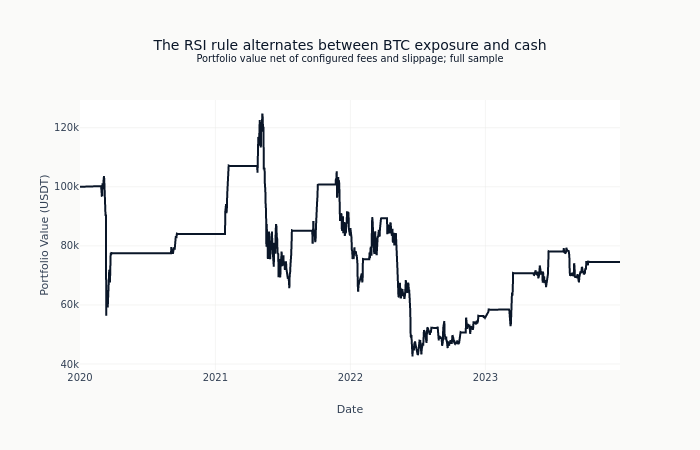

In [21]:
ec = results.equity
fig = go.Figure(
    go.Scatter(
        x=ec.timestamps,
        y=ec.values,
        name="Portfolio Value",
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig.update_layout(
    title=(
        "The RSI rule alternates between BTC exposure and cash"
        "<br><sup>Portfolio value net of configured fees and slippage; full sample</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Portfolio Value (USDT)",
    height=450,
    hovermode="x unified",
)
fig.show()

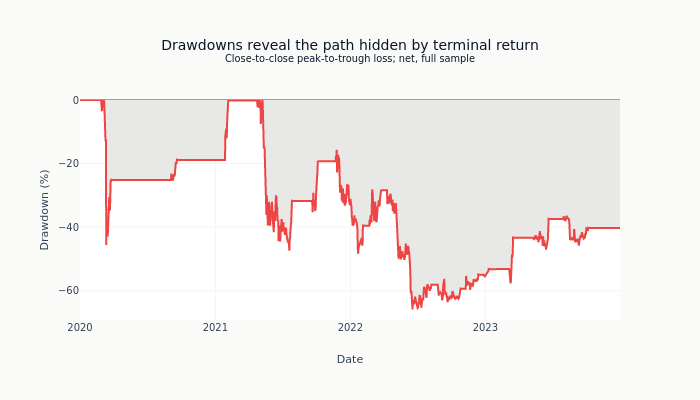

In [22]:
drawdown_pct = ec.drawdown_series() * 100
drawdown_floor = min(float(drawdown_pct.min()) * 1.05, -1.0)
fig_dd = go.Figure(
    go.Scatter(
        x=ec.timestamps,
        y=drawdown_pct,
        name="Drawdown",
        fill="tozeroy",
        fillcolor=COLORS["silver_muted"],
        line=dict(color=COLORS["negative"]),
    )
)
fig_dd.update_layout(
    title=(
        "Drawdowns reveal the path hidden by terminal return"
        "<br><sup>Close-to-close peak-to-trough loss; net, full sample</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    yaxis_range=[drawdown_floor, 0],
    height=400,
    hovermode="x unified",
)
fig_dd.show()

## 8. Compare to Buy-and-Hold Benchmark

A benchmark is useful only under a comparable protocol. The buy-and-hold strategy below uses the
same engine, 95% signal-time target, next-open execution, fractional units, fee and slippage rates,
crypto annualization, and sample. Its single entry remains open at the sample end.

In [23]:
class BuyAndHoldStrategy(Strategy):
    """Submit one target-weight entry and retain it through the sample."""

    def __init__(self, position_size: float = 0.95):
        self.position_size = position_size
        self.submitted = False

    def on_data(self, timestamp, data, context, broker):
        """Submit the benchmark entry on the first available bar."""
        asset = "BTCUSDT"
        if not self.submitted and data.get(asset) is not None:
            broker.order_target_percent(asset, self.position_size)
            self.submitted = True

In [24]:
benchmark_feed = DataFeed(prices_df=prices_df)
benchmark_engine = Engine(
    feed=benchmark_feed,
    strategy=BuyAndHoldStrategy(position_size=POSITION_SIZE),
    config=config,
)
benchmark_results = benchmark_engine.run()
assert benchmark_results.equity is not None
assert benchmark_results.equity.periods_per_year == 365
assert len(benchmark_results.fills) == 1
assert len(benchmark_results.trades) == 1
assert benchmark_results.trades[0].status == "open"

**Protocol-matched strategy comparison** (daily returns annualized with 365 crypto periods):

In [25]:
comparison = pl.DataFrame(
    {
        "metric": ["Total return (%)", "Sharpe ratio", "Max drawdown (%)", "Fill count"],
        "rsi_strategy": [
            float(results["total_return_pct"]),
            float(results["sharpe"]),
            float(results["max_drawdown_pct"]),
            float(len(results.fills)),
        ],
        "buy_and_hold": [
            float(benchmark_results["total_return_pct"]),
            float(benchmark_results["sharpe"]),
            float(benchmark_results["max_drawdown_pct"]),
            float(len(benchmark_results.fills)),
        ],
    }
)
comparison.with_columns(pl.col(["rsi_strategy", "buy_and_hold"]).round(3))

metric,rsi_strategy,buy_and_hold
str,f64,f64
"""Total return (%)""",-25.472,463.356
"""Sharpe ratio""",0.09,0.991
"""Max drawdown (%)""",65.913,76.254
"""Fill count""",28.0,1.0


In [26]:
strategy_return = float(results["total_return_pct"])
benchmark_return = float(benchmark_results["total_return_pct"])
return_leader = "Buy-and-hold" if benchmark_return > strategy_return else "The RSI strategy"
display(
    Markdown(
        f"**{return_leader}** leads total return in this sample: **{benchmark_return:.2f}%** "
        f"for buy-and-hold versus **{strategy_return:.2f}%** for RSI. Their Sharpe ratios are "
        f"**{benchmark_results['sharpe']:.2f}** and **{results['sharpe']:.2f}**; maximum "
        f"drawdowns are **-{benchmark_results['max_drawdown_pct']:.2f}%** and "
        f"**-{results['max_drawdown_pct']:.2f}%**, respectively. This is an in-sample exposure "
        "comparison, not evidence that either rule will dominate out of sample."
    )
)

**Buy-and-hold** leads total return in this sample: **463.36%** for buy-and-hold versus **-25.47%** for RSI. Their Sharpe ratios are **0.99** and **0.09**; maximum drawdowns are **-76.25%** and **-65.91%**, respectively. This is an in-sample exposure comparison, not evidence that either rule will dominate out of sample.

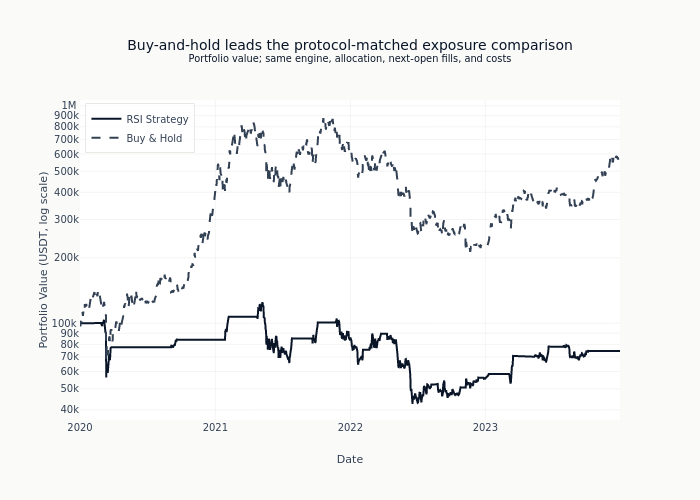

In [27]:
benchmark_ec = benchmark_results.equity
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=ec.timestamps,
        y=ec.values,
        name="RSI Strategy",
        line=dict(color=COLORS["blue"]),
    )
)
fig.add_trace(
    go.Scatter(
        x=benchmark_ec.timestamps,
        y=benchmark_ec.values,
        name="Buy & Hold",
        line=dict(color=COLORS["neutral"], dash="dash"),
    )
)
fig.update_layout(
    title=(
        f"{return_leader} leads the protocol-matched exposure comparison"
        "<br><sup>Portfolio value; same engine, allocation, next-open fills, and costs</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Portfolio Value (USDT, log scale)",
    yaxis_type="log",
    yaxis_tickformat="~s",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    hovermode="x unified",
)
fig.show()

## 9. MFE/MAE Analysis

Maximum favorable excursion (MFE) and maximum adverse excursion (MAE) expose each closed trade's
path between entry and exit. The full-sample levels below are retrospective diagnostics. Without
a sealed validation sample, they are not optimized stop-loss or take-profit recommendations.

In [28]:
mfe_analyzer = MAEMFEAnalyzer(closed_trades)
levels = mfe_analyzer.optimal_exit_levels()
excursion_df = trades_df.with_row_index("trade_id", offset=1)

Bars show the best and worst marked return reached during each trade; diamonds show the terminal
realized return. The chart keeps adverse excursions below zero.

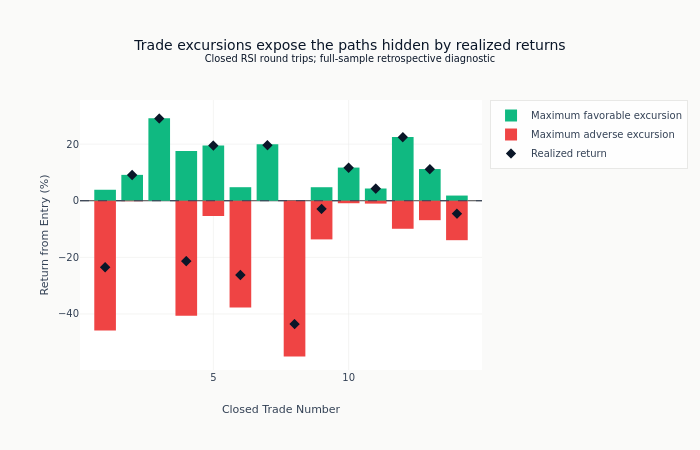

In [29]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=excursion_df["trade_id"],
        y=excursion_df["mfe"] * 100,
        name="Maximum favorable excursion",
        marker_color=COLORS["positive"],
    )
)
fig.add_trace(
    go.Bar(
        x=excursion_df["trade_id"],
        y=excursion_df["mae"] * 100,
        name="Maximum adverse excursion",
        marker_color=COLORS["negative"],
    )
)
fig.add_trace(
    go.Scatter(
        x=excursion_df["trade_id"],
        y=excursion_df["pnl_percent"] * 100,
        name="Realized return",
        mode="markers",
        marker=dict(color=COLORS["blue"], size=8, symbol="diamond"),
    )
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title=(
        "Trade excursions expose the paths hidden by realized returns"
        "<br><sup>Closed RSI round trips; full-sample retrospective diagnostic</sup>"
    ),
    xaxis_title="Closed Trade Number",
    yaxis_title="Return from Entry (%)",
    barmode="relative",
    height=450,
)
fig.show()

In [30]:
display(
    Markdown(
        f"The closed trades have an **{mfe_analyzer.edge_ratio:.2f} MFE-to-|MAE| edge ratio**. "
        f"The analyzer's full-sample percentile references are **{levels['stop_loss']:.2%}** for "
        f"adverse excursion and **{levels['take_profit']:.2%}** for favorable excursion, with a "
        f"**{levels['risk_reward']:.2f}** ratio. These levels require separate validation before "
        "they can enter a trading rule."
    )
)

The closed trades have an **0.69 MFE-to-|MAE| edge ratio**. The analyzer's full-sample percentile references are **-7.78%** for adverse excursion and **4.44%** for favorable excursion, with a **0.57** ratio. These levels require separate validation before they can enter a trading rule.

## 10. Relating the Event-Driven and Vectorized Implementations

Notebook 03 and this notebook now share the same BTC input, UTC-day aggregation, simple rolling
RSI, prior-close decision timing, next-open fill convention, fractional units, and percentage
costs. One deliberate sizing detail remains visible:

- **VectorBT** resolves the 95% percentage size at the execution row's open.
- **ml4t-backtest** converts the 95% signal-time target into units at the decision close, queues
  those units, and fills them at the next open. An overnight gap therefore moves the realized
  fill-time weight away from exactly 95%.

Headline differences alone cannot identify a cause. Notebook 06 isolates engine conventions under
a dedicated parity contract rather than attributing any residual gap after the fact.

**Execution approach: VectorBT vs ml4t-backtest.**

| Aspect              | VectorBT (NB 03)     | ml4t-backtest (NB 04)    |
|---------------------|----------------------|--------------------------|
| Execution model     | Vectorized           | Event-driven             |
| Order representation | Timestamped signals | Pending order objects    |
| Position state      | Portfolio simulation | Explicit broker state    |
| Parameter analysis  | Natural array workflow | Repeated sequential runs |
| Trade path records  | Portfolio records    | Per-trade state and excursions |

## See Also

- **`03_single_asset_vectorbt`** implements the common RSI rule with an array-oriented portfolio.
- **`06_framework_parity`** aligns engine conventions under a dedicated parity contract.
- **`09_performance_reporting`** extends the result into a diagnostic report.

## Key Takeaways

The synthesis below is generated from the current run so its result statements remain aligned
with the executed notebook.

In [31]:
display(
    Markdown(
        f"""
### 1. Sequential state is the reason to use the event loop

`DataFeed`, `Strategy`, `Engine`, and `Broker` make decisions, pending orders, fills, cash, and
positions explicit. That visibility supports path-dependent logic, but does not make unspecified
assumptions realistic.

### 2. Event ordering is part of the strategy definition

The {RSI_PERIOD}-day close-derived RSI is observed after the UTC day closes. `NEXT_BAR` then fills
the queued fractional order at the next open. The 95% target is converted to units at signal time,
so an overnight gap can move the realized fill-time weight.

### 3. Accounting should reconcile independently

The run completes **{len(closed_trades)} closed round trips**. Reference-price P&L less modeled
slippage and commission reconciles to closed-trade net P&L within the asserted tolerance.

### 4. Benchmarks and diagnostics need the same protocol boundary

**{return_leader}** leads this matched in-sample comparison. MFE/MAE levels describe the observed
trade paths; they are not validated exit rules.

**Next:** `06_framework_parity` isolates engine semantics, and `09_performance_reporting` builds the
reporting layer described in Chapter 16, Sections 16.3-16.5.
"""
    )
)


### 1. Sequential state is the reason to use the event loop

`DataFeed`, `Strategy`, `Engine`, and `Broker` make decisions, pending orders, fills, cash, and
positions explicit. That visibility supports path-dependent logic, but does not make unspecified
assumptions realistic.

### 2. Event ordering is part of the strategy definition

The 14-day close-derived RSI is observed after the UTC day closes. `NEXT_BAR` then fills
the queued fractional order at the next open. The 95% target is converted to units at signal time,
so an overnight gap can move the realized fill-time weight.

### 3. Accounting should reconcile independently

The run completes **14 closed round trips**. Reference-price P&L less modeled
slippage and commission reconciles to closed-trade net P&L within the asserted tolerance.

### 4. Benchmarks and diagnostics need the same protocol boundary

**Buy-and-hold** leads this matched in-sample comparison. MFE/MAE levels describe the observed
trade paths; they are not validated exit rules.

**Next:** `06_framework_parity` isolates engine semantics, and `09_performance_reporting` builds the
reporting layer described in Chapter 16, Sections 16.3-16.5.
